# FlyRank Capstone — Predicting Next-Month Search-Impression Decline

**Lane:** Refresh / Content Opportunity Scoring  
**Research question:** Can a transparent March-only model identify pages at risk of a ≥20% decrease in April impressions better than a visibility-only ranking?  
**Author:** Mehdi Dardour  
**Data:** FlyRank pseudonymized internship warehouse, March–April 2026  
**Purpose:** Editorial decision support, not autonomous action or proof of refresh effectiveness.

This notebook follows the seven sections requested in the FlyRank capstone skeleton and evaluates a Random Forest and baseline on the **same held-out clients**. It produces aggregate-only charts and metrics. **Never commit or publish the input CSV, hashed IDs, or individual-page scores.**

## 1. Question

A FlyRank editor has limited time to audit content. The **unit of analysis** is one pseudonymized client–page pair. The output is a **ranked risk score** for a meaningful fall in Google Search Console impressions in the following month. An editor would review high-risk pages for content quality, indexing problems, seasonality, and search intent before deciding whether to refresh them. False positives waste editorial time; false negatives miss potential opportunities. Ranking can help triage a large portfolio, but does not demonstrate that a refresh would avert an observed decline.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

SEED = 42
FEATURES = ["impressions", "clicks", "ctr", "avg_position", "active_days"]
# Works when notebook is at repo root OR at work/notebooks/.
search_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent,
                Path.cwd() / "work" / "notebooks"]
candidates = [root / "flyrank_march_april_model_data.csv" for root in search_roots]
CSV_PATH = next((p for p in candidates if p.is_file()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "Place flyrank_march_april_model_data.csv at the repo root, then Run All. "
        "Do NOT commit this private file."
    )
REPO_ROOT = CSV_PATH.parent
OUTPUT_DIR = REPO_ROOT / "outputs" / "capstone"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Private input located; output directory:", OUTPUT_DIR)

Private input located; output directory: /Users/mehdidardour/FlyrankAI-ML/work/notebooks/outputs/capstone


## 2. Data

The features are built from **March 1–31, 2026** GSC observations, using the gated `FlyRank/internship-warehouse` daily content-performance table. The outcome uses **April 1–30, 2026** observations, joined by pseudonymous client and page IDs. A row represents one client–content item after aggregation.

**Features available at the March decision point:** total March impressions, March clicks, March CTR (percent), mean March search position, and count of days with positive impressions. **Excluded from features:** April impressions, any April-derived labels, `trend_direction`, `trend_pct`, hashed identifiers, URLs, queries, and content/client metadata. Identifiers are retained only for grouping and checking duplicates.

Caveat: The upstream feature construction used an **inner join** with April, dropping pages without observed April records. This risks survivorship/selection bias; April-missing pages cannot be assumed to have zero impressions.

In [2]:
d = pd.read_csv(CSV_PATH)
required = FEATURES + ["client_hash_id", "content_hash_id", "april_impressions", "is_future_decline"]
assert set(required).issubset(d.columns), f"Missing columns: {set(required) - set(d.columns)}"
assert d[required].notna().all().all(), "Unexpected missing values"
assert not d[["client_hash_id", "content_hash_id"]].duplicated().any(), "Duplicate page/client keys"
assert d["is_future_decline"].isin([0, 1]).all()
assert (d["is_future_decline"].to_numpy() ==
        (d["april_impressions"].to_numpy() < .8 * d["impressions"].to_numpy()).astype(int)).all()
assert (d[["impressions", "clicks", "april_impressions"]] >= 0).all().all()
summary = pd.DataFrame({"quantity": ["Pages", "Clients", "Overall decline rate"],
                        "value": [len(d), d.client_hash_id.nunique(), round(d.is_future_decline.mean(), 4)]})
display(summary)
# Never display client_hash_id, content_hash_id, or page-level records in outputs.

,quantity,value
0,Pages,158549.0000
1,Clients,46.0000
2,Overall decline rate,0.4782


## 3. Methodology

**Proxy outcome:** `is_future_decline = 1` if April impressions are **strictly less than 80%** of March impressions. It is a directional next-month decline indicator, not evidence of an intervention effect. The label is constructed from April only **after** March features are computed.

**Baseline:** rank pages by descending `log(1 + March impressions)`, a simple and reproducible visibility-prioritization rule; higher exposure is assumed to merit earlier editorial review. This is intentionally simpler than the prior Week 4 heuristic and must not be confused with that previous result.

**ML method:** Random Forest, 150 trees, `min_samples_leaf=10`, `max_features="sqrt"`, seed 42; fit only on five March features. **Validation:** one reproducible `GroupShuffleSplit(test_size=0.25, random_state=42)`, grouping on client ID, so no client occurs in both partitions. This protects against same-client memorization but does **not** validate across multiple calendar periods.

**Primary evaluation:** pooled Precision@50 with ROC AUC and Average Precision. Report the held-out base rate. Also summarize per-client top-50 precision for clients with at least 50 pages. All comparisons use the **identical held-out rows**.

In [3]:
splitter = GroupShuffleSplit(n_splits=1, test_size=.25, random_state=SEED)
tr_idx, te_idx = next(splitter.split(d, groups=d["client_hash_id"]))
train, test = d.iloc[tr_idx].copy(), d.iloc[te_idx].copy()
assert set(train.client_hash_id).isdisjoint(set(test.client_hash_id))
rf = RandomForestClassifier(n_estimators=150, min_samples_leaf=10,
                            max_features="sqrt", random_state=SEED, n_jobs=-1)
rf.fit(train[FEATURES], train["is_future_decline"])
y = test["is_future_decline"].to_numpy()
model_scores = rf.predict_proba(test[FEATURES])[:, 1]
baseline_scores = np.log1p(test["impressions"].clip(lower=0).to_numpy())

def precision_at_k(labels, scores, k):
    ordered = np.argsort(-np.asarray(scores), kind="stable")[:min(k, len(scores))]
    return float(np.asarray(labels)[ordered].mean())

def evaluate(scores):
    return {"ROC AUC": roc_auc_score(y, scores),
            "Average precision": average_precision_score(y, scores),
            "Precision@20": precision_at_k(y, scores, 20),
            "Precision@50": precision_at_k(y, scores, 50),
            "Precision@100": precision_at_k(y, scores, 100),
            "Precision@500": precision_at_k(y, scores, 500)}
results = pd.DataFrame({"Baseline (visibility)": evaluate(baseline_scores),
                        "Random Forest": evaluate(model_scores)})
print(f"Train: {len(train):,} pages from {train.client_hash_id.nunique()} clients")
print(f"Test: {len(test):,} pages from {test.client_hash_id.nunique()} clients")
print(f"Held-out decline base rate: {y.mean():.2%}; majority class: {max(y.mean(), 1-y.mean()):.2%}")

Train: 135,314 pages from 34 clients
Test: 23,235 pages from 12 clients
Held-out decline base rate: 46.99%; majority class: 53.01%


## 4. Results (vs baseline)

All metrics below are computed on the **same 12 completely held-out clients**. The benchmark dataset includes **158,549 pages from 46 clients**; 135,314 pages / 34 clients were used for training and 23,235 pages / 12 clients for testing. The observed decline rate is **47.82% overall** and **46.99% on test** (test majority class: 53.01%).

On this fixed split, the **Random Forest achieved Precision@50 = 0.80 vs 0.36** for the visibility baseline (**40/50 vs 18/50** observed future-decline pages). ROC AUC improved from **0.570 to 0.701** and Average Precision from **0.492 to 0.636**. These top-k metrics are **global rankings pooled across test clients**, not average performance for a typical client. Scores are predictive ranking signals, not measured editorial impact.

In [4]:
display(results.style.format("{:.3f}"))
assert np.isclose(results.loc["Precision@50", "Random Forest"], .80)
assert np.isclose(results.loc["Precision@50", "Baseline (visibility)"], .36)

ranked = test[["client_hash_id", "is_future_decline"]].copy()
ranked["model_score"] = model_scores
ranked["baseline_score"] = baseline_scores
per_client = []
for _, group in ranked.groupby("client_hash_id"):
    if len(group) >= 50:
        per_client.append({"n_pages":len(group),
                           "model_p50":precision_at_k(group.is_future_decline, group.model_score, 50),
                           "baseline_p50":precision_at_k(group.is_future_decline, group.baseline_score, 50)})
per_client_summary = pd.DataFrame(per_client)
print("Clients with >=50 test pages:", len(per_client_summary))
print("Client-macro P@50 — RF:", round(per_client_summary.model_p50.mean(),3),
      "baseline:", round(per_client_summary.baseline_p50.mean(),3))
# For a compact error audit, probability >=0.5 is an illustrative threshold, NOT editorial policy.
errors = confusion_matrix(y, model_scores >= .5, labels=[0, 1])
print("Confusion matrix [[TN, FP],[FN, TP]] at threshold .5:")
print(errors)
print("Top-50 false positives:", round(50*(1-results.loc["Precision@50", "Random Forest"])))

,Baseline (visibility),Random Forest
ROC AUC,0.570,0.700
Average precision,0.492,0.636
Precision@20,0.550,0.800
Precision@50,0.360,0.800
Precision@100,0.350,0.730
Precision@500,0.372,0.702


Clients with >=50 test pages: 7
Client-macro P@50 — RF: 0.491 baseline: 0.231
Confusion matrix [[TN, FP],[FN, TP]] at threshold .5:
[[8375 3942]
 [4329 6589]]
Top-50 false positives: 10


## 5. Limitations

1. **Non-causal:** an impression decline is not proof of a content problem, and successful prediction does not imply a refresh will help.
2. **April inner-join selection:** pages absent in April were excluded, potentially biasing the target population.
3. **One train/test split, one month pair:** this does not prove stability across seasons, new clients, or alternate time windows; repeat with several seeds and additional chronological holdouts before production.
4. **Different client sizes:** global Precision@50 can be dominated by large clients; per-client macro precision is reported separately.
5. **Baseline scope:** the simple visibility score is not the previous Week 4 rule. This benchmark does not assert improvement over that earlier heuristic.
6. **Threshold effects:** the 20% decline cutoff and 0.5 classification threshold are choices, not objectively optimal business thresholds. Small-denominator and tracking effects can distort changes.
7. **GSC limitations:** tracking availability, seasonality, noise, and search position aggregation can influence observed performance.

No private client names, URLs, or query text should appear in repository artifacts or the published paper.

In [5]:
imp = (pd.Series(rf.feature_importances_, index=FEATURES)
       .sort_values(ascending=False).rename("Gini importance"))
display(imp.to_frame().style.format("{:.3f}"))
print("Top model predictors (association, not causation):", ", ".join(imp.index[:3]))
print("Model top-50 false positives:", int(50 - round(50 * results.loc["Precision@50", "Random Forest"])))

,Gini importance
avg_position,0.323
impressions,0.292
active_days,0.190
ctr,0.132
clicks,0.064


Top model predictors (association, not causation): avg_position, impressions, active_days
Model top-50 false positives: 10


## 6. Ranked recommendations

**Editorial workflow** (a recommended process, not a causal intervention result):

1. **Prioritize** pages with the largest model risk scores for the next-month decline proxy.
2. **Review** high-risk pages in a human audit: search-intent fit, indexing status, content freshness, competing pages, reporting anomalies, and seasonal context.
3. **Select actions** only after diagnosing the issue: update the content, correct technical issues, consolidate overlaps, or deliberately take no action.
4. **Record** the decision and reason; monitor future impressions, but do not infer causal uplift from before–after observation alone.
5. **Evaluate** a controlled editorial experiment before claiming that risk-based triage improves business outcomes.

The code below produces only aggregate top-k yield, **not a list of hashed page IDs or client identifiers**. Editorial score exports should occur solely in an approved private environment.

In [6]:
ks = [20, 50, 100, 500]
recommendation_yield = pd.DataFrame({
    "top_k":ks,
    "model_declines_observed":[int(round(k*precision_at_k(y, model_scores,k))) for k in ks],
    "baseline_declines_observed":[int(round(k*precision_at_k(y, baseline_scores,k))) for k in ks],
    "base_rate_expected":[round(k*y.mean(), 1) for k in ks],
})
display(recommendation_yield)
print("No individual-page or client-level export created.")

,top_k,model_declines_observed,baseline_declines_observed,base_rate_expected
0,20,16,11,9.4
1,50,40,18,23.5
2,100,73,35,47.0
3,500,351,186,234.9


No individual-page or client-level export created.


## 7. Artifacts the paper embeds

Generate two **aggregate-only** plots: (1) model vs baseline Precision@K with the held-out base-rate reference and (2) Random Forest feature importances. Export the comparison table and a JSON summary for the research paper. No private IDs or page-level predictions are saved. The paper is represented by `paper.md` and `docs/index.html` elsewhere in the repo; re-check all reported values after any change to the split or model.

**Reproduce:** install `pandas`, `numpy`, `matplotlib`, `scikit-learn`; place the approved input CSV at the repository root (ignored by Git); open `work/notebooks/capstone.ipynb`; choose that Python kernel; **Run All**. Seed: 42. The notebook searches the repo root if run from `work/notebooks`.

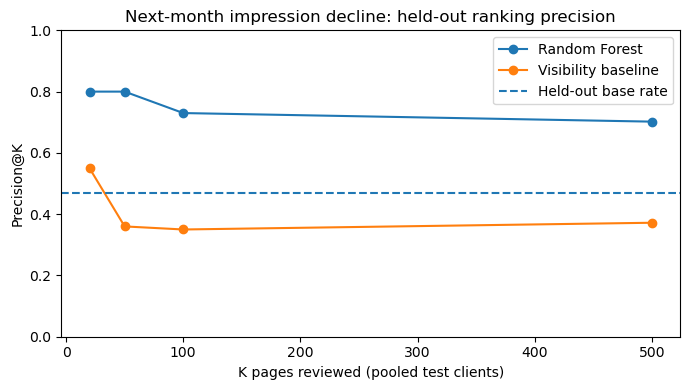

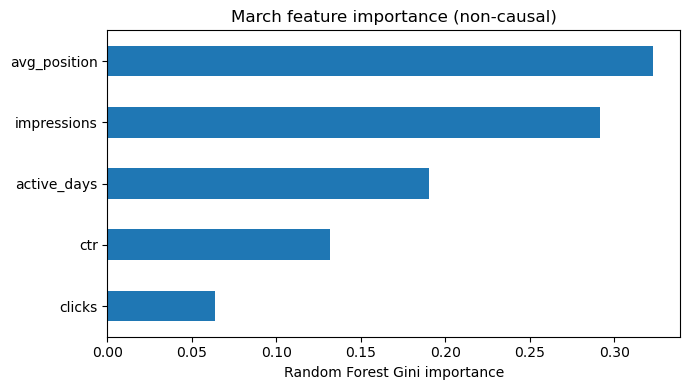

Saved aggregate-only artifacts in /Users/mehdidardour/FlyrankAI-ML/work/notebooks/outputs/capstone


In [7]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ks, [precision_at_k(y, model_scores,k) for k in ks], marker="o", label="Random Forest")
ax.plot(ks, [precision_at_k(y, baseline_scores,k) for k in ks], marker="o", label="Visibility baseline")
ax.axhline(y.mean(), linestyle="--", label="Held-out base rate")
ax.set(xlabel="K pages reviewed (pooled test clients)", ylabel="Precision@K",
       title="Next-month impression decline: held-out ranking precision", ylim=(0,1))
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "precision_at_k.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
imp.sort_values().plot.barh(ax=ax)
ax.set(xlabel="Random Forest Gini importance", title="March feature importance (non-causal)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "feature_importance.png", dpi=160)
plt.show()

results.to_csv(OUTPUT_DIR / "comparison.csv")
public_summary = {
    "n_pages":int(len(d)), "n_clients":int(d.client_hash_id.nunique()),
    "n_train_pages":int(len(train)), "n_test_pages":int(len(test)),
    "train_clients":int(train.client_hash_id.nunique()),
    "test_clients":int(test.client_hash_id.nunique()),
    "overall_base_rate":float(d.is_future_decline.mean()),
    "test_base_rate":float(y.mean()),
    "model": {k:float(v) for k,v in results["Random Forest"].items()},
    "baseline": {k:float(v) for k,v in results["Baseline (visibility)"].items()},
    "per_client_macro_p50":{
        "model":float(per_client_summary.model_p50.mean()),
        "baseline":float(per_client_summary.baseline_p50.mean()),
        "eligible_clients":int(len(per_client_summary))},
    "feature_importance":{k:float(v) for k,v in imp.items()},
    "seed":SEED,
    "note":"Predictive, observational; no causal refresh-effect claim."
}
(OUTPUT_DIR / "public_aggregate_summary.json").write_text(json.dumps(public_summary,indent=2))
print("Saved aggregate-only artifacts in", OUTPUT_DIR)

## Self-check

- [x] All seven sections contain a narrative and supporting code or substantive analysis.
- [ ] **Run All completed successfully in your own VS Code environment** (confirm before submission).
- [x] Group-disjoint client holdout; five March-only model features; no hashed identifiers or April values used as features.
- [x] Model and baseline compared on the identical test set with held-out base rate reported.
- [x] Metrics and visualizations exported as aggregates only; do not commit the private CSV.
- [ ] **Review the repo's other `work/` artifacts to confirm** none contain client names, URLs, private queries, or individual-level outputs.
- [x] No claims about Google's algorithm or causal effects of refreshing content.
- [ ] Reconcile `paper.md`, `docs/index.html`, and `work/capstone_report.md` with a fresh execution before publishing.
- [ ] Commit `work/notebooks/capstone.ipynb` (and approved aggregate artifacts) only after checking repo policy.